
# Fine-tuning com LoRA: Arquitetura Modernista de Brasília

Este notebook faz a **Etapa 2** do projeto Ateliê Generativo: fine-tuning do Stable Diffusion c




```
# Isto está formatado como código
```

## Conectar ao Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')



## 1. Instalar dependências e clonar o script oficial de treino



In [ ]:
!git clone https://github.com/huggingface/diffusers /content/diffusers
%cd /content/diffusers/examples/text_to_image
!pip install -q -r requirements.txt
!pip install -q accelerate peft datasets torchvision

# Instala o diffusers a partir do source clonad
!pip install -e /content/diffusers

# Remove o torchao pré-instalado no Colab
!pip uninstall -y -q torchao


In [ ]:
import importlib
import diffusers

importlib.reload(diffusers)

try:
    versao = diffusers.__version__
except AttributeError:
    # fallback caso o atributo não esteja exposto diretamente no módulo
    from importlib.metadata import version as pkg_version
    versao = pkg_version("diffusers")

print("Versão do diffusers instalada:", versao)
print("Localização do pacote:", diffusers.__file__)




## 2. Login no Hugging Face



In [ ]:
from huggingface_hub import notebook_login
notebook_login()


## 3. Configuração

In [ ]:
import os

# Pasta do dataset gerado na Etapa 1
DADOS_DIR = "/content/drive/MyDrive/atelie-generativo/dados"
IMAGENS_DIR = os.path.join(DADOS_DIR, "imagens")
LEGENDAS_TXT = os.path.join(DADOS_DIR, "legendas.txt")

# Pasta de treino: uma cópia com metadata.jsonl no formato que o script espera
TREINO_DIR = "/content/drive/MyDrive/atelie-generativo/treino_dataset"
os.makedirs(TREINO_DIR, exist_ok=True)

# Saída dos dois experimentos de LoRA
SAIDA_RANK8 = "/content/drive/MyDrive/atelie-generativo/lora_rank8"
SAIDA_RANK16 = "/content/drive/MyDrive/atelie-generativo/lora_rank16"
os.makedirs(SAIDA_RANK8, exist_ok=True)
os.makedirs(SAIDA_RANK16, exist_ok=True)

MODELO_BASE = "stable-diffusion-v1-5/stable-diffusion-v1-5"

# Prompt de validação
PROMPT_VALIDACAO = "estilo_brasilia, uma escola modernista com colunas curvas de concreto branco"


HUB_MODEL_ID_RANK8 = "andre-lla/lora-brasilia-rank8"
HUB_MODEL_ID_RANK16 = "andre-lla/lora-brasilia-rank16"

print("Configuração pronta.")



## 4. Preparar o dataset no formato esperado pelo script




In [ ]:
import json
import shutil

linhas_processadas = 0
with open(LEGENDAS_TXT, "r", encoding="utf-8") as f_legendas, \
     open(os.path.join(TREINO_DIR, "metadata.jsonl"), "w", encoding="utf-8") as f_metadata:

    for linha in f_legendas:
        linha = linha.strip()
        if not linha or "|" not in linha:
            continue
        arquivo, legenda = linha.split("|", 1)
        arquivo = arquivo.strip()
        legenda = legenda.strip()

        origem = os.path.join(IMAGENS_DIR, arquivo)
        destino = os.path.join(TREINO_DIR, arquivo)
        if not os.path.exists(origem):
            print(f"⚠️ Imagem não encontrada, pulando: {arquivo}")
            continue

        shutil.copyfile(origem, destino)
        f_metadata.write(json.dumps({"file_name": arquivo, "text": legenda}, ensure_ascii=False) + "\n")
        linhas_processadas += 1

print(f"{linhas_processadas} imagens + legendas preparadas em: {TREINO_DIR}")

if linhas_processadas < 20:
    print("⚠️ Menos de 20 imagens processadas — confira se legendas.txt está no formato 'arquivo | legenda'")



## GPU




In [ ]:
import torch

if torch.cuda.is_available():
    print("✅ GPU detectada:", torch.cuda.get_device_name(0))
else:
    print("🚫 Nenhuma GPU detectada — o treino vai rodar em CPU e ser extremamente lento.")
    print("   Vá em Ambiente de execução → Alterar tipo de ambiente → selecione T4 GPU → Salvar")
    print("   (isso reinicia a sessão; depois rode as células novamente em ordem a partir da Seção 1)")



## 5. Configuração — rank 8


**Hiperparâmetros usados aqui e por quê:**
- `rank=8`: rank maior com poucos dados aumenta risco
  de overfitting
- `max_train_steps=1500`:
- `learning_rate=1e-4`: dentro da faixa recomendada pra LoRA (1e-4 a 5e-5)
- `mixed_precision=fp16`: necessário pra caber na VRAM de 16GB da T4


In [ ]:
!accelerate launch train_text_to_image_lora.py \
  --pretrained_model_name_or_path="{MODELO_BASE}" \
  --train_data_dir="{TREINO_DIR}" \
  --resolution=512 --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1500 \
  --learning_rate=1e-4 --lr_scheduler="cosine" \
  --rank=8 \
  --mixed_precision="fp16" \
  --checkpointing_steps=500 \
  --validation_prompt="{PROMPT_VALIDACAO}" \
  --num_validation_images=4 \
  --output_dir="{SAIDA_RANK8}" \
  --push_to_hub --hub_model_id="{HUB_MODEL_ID_RANK8}"



## 6. Configuração — rank 16



In [ ]:
!accelerate launch train_text_to_image_lora.py \
  --pretrained_model_name_or_path="{MODELO_BASE}" \
  --train_data_dir="{TREINO_DIR}" \
  --resolution=512 --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --max_train_steps=1500 \
  --learning_rate=5e-5 --lr_scheduler="cosine" \
  --rank=16 \
  --mixed_precision="fp16" \
  --checkpointing_steps=500 \
  --validation_prompt="{PROMPT_VALIDACAO}" \
  --num_validation_images=4 \
  --output_dir="{SAIDA_RANK16}" \
  --push_to_hub --hub_model_id="{HUB_MODEL_ID_RANK16}"



## Reiniciar a sessão para a etapa de geração/comparação

Problema com versões dos pacotes de Torch



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q --no-deps diffusers transformers accelerate

!pip install -q safetensors huggingface_hub regex tokenizers

!pip uninstall -y -q torchao


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo detectado:", DEVICE)

if DEVICE == "cpu":
    print("⚠️ Sem GPU disponível — vai rodar em CPU. Bem mais lento (alguns minutos por imagem",
          "em vez de segundos), mas funciona. Isso costuma acontecer quando a cota gratuita de",
          "GPU do Colab está temporariamente esgotada.")
else:
    print("✅ GPU disponível:", torch.cuda.get_device_name(0))


Dispositivo detectado: cpu
⚠️ Sem GPU disponível — vai rodar em CPU. Bem mais lento (alguns minutos por imagem em vez de segundos), mas funciona. Isso costuma acontecer quando a cota gratuita de GPU do Colab está temporariamente esgotada.


In [ ]:
import os

DADOS_DIR = "/content/drive/MyDrive/atelie-generativo/dados"
MODELO_BASE = "stable-diffusion-v1-5/stable-diffusion-v1-5"
PROMPT_VALIDACAO = "estilo_brasilia, uma escola modernista com colunas curvas de concreto branco"

SAIDA_RANK8 = "/content/drive/MyDrive/atelie-generativo/lora_rank8"
SAIDA_RANK16 = "/content/drive/MyDrive/atelie-generativo/lora_rank16"

print("Variáveis recriadas. Pronto para a Seção 7.")


Variáveis recriadas. Pronto para a Seção 7.



## 7. Gerar e comparar as imagens de validação dos dois checkpoints





In [ ]:
import glob
import torch
from diffusers import StableDiffusionPipeline

SEMENTE = 42  # mesma seed base para todas as configs, para a comparação ser justa
PASTA_COMPARACAO = "/content/drive/MyDrive/atelie-generativo/comparacao_validacao"
os.makedirs(PASTA_COMPARACAO, exist_ok=True)


def resolver_caminho_pesos(pasta_base):
    # Retorna a pasta com os pesos finais do LoRA, ou o checkpoint mais recente disponível
    # caso o treino tenha sido interrompido antes de salvar os pesos finais.
    peso_final = os.path.join(pasta_base, "pytorch_lora_weights.safetensors")
    if os.path.exists(peso_final):
        return pasta_base

    checkpoints = sorted(
        glob.glob(os.path.join(pasta_base, "checkpoint-*")),
        key=lambda p: int(p.split("-")[-1]),
    )
    for cp in reversed(checkpoints):
        if os.path.exists(os.path.join(cp, "pytorch_lora_weights.safetensors")):
            print(f"⚠️ Pesos finais não encontrados em {pasta_base}; usando '{os.path.basename(cp)}' "
                  f"(o treino provavelmente foi interrompido antes de terminar todos os passos).")
            return cp

    raise FileNotFoundError(f"Nenhum peso de LoRA encontrado em {pasta_base} nem em seus checkpoints.")


def carregar_pipeline(lora_dir):
    caminho_resolvido = resolver_caminho_pesos(lora_dir)
    # float16 só é bem suportado em GPU; em CPU usamos float32
    dtype = torch.float16 if DEVICE == "cuda" else torch.float32
    pipe = StableDiffusionPipeline.from_pretrained(
        MODELO_BASE, torch_dtype=dtype, safety_checker=None
    ).to(DEVICE)
    pipe.load_lora_weights(caminho_resolvido)
    return pipe


# Menos passos de inferência em CPU, para não ficar excessivamente lento —
# a diferença de qualidade entre 20 e 30 passos costuma ser pequena.
PASSOS_INFERENCIA = 30 if DEVICE == "cuda" else 20


def gerar_imagens(pipe, prompt, rotulo, pasta_saida, n=4, semente_base=SEMENTE):
    os.makedirs(pasta_saida, exist_ok=True)
    caminhos = []
    for i in range(n):
        gerador = torch.Generator(DEVICE).manual_seed(semente_base + i)
        imagem = pipe(
            prompt, num_inference_steps=PASSOS_INFERENCIA, guidance_scale=7.5, generator=gerador
        ).images[0]
        caminho = os.path.join(pasta_saida, f"{rotulo}_{i}.png")
        imagem.save(caminho)
        caminhos.append(caminho)
    return caminhos


def gerar_imagens_validacao(lora_dir, rotulo, pasta_saida, n=4):
    pipe = carregar_pipeline(lora_dir)
    caminhos = gerar_imagens(pipe, PROMPT_VALIDACAO, f"{rotulo}_validacao", pasta_saida, n=n)
    del pipe
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return caminhos


N_VALIDACAO = 4 if DEVICE == "cuda" else 2  # menos imagens em CPU, para não ficar muito lento

print("Gerando imagens — rank 8...")
imgs_rank8 = gerar_imagens_validacao(SAIDA_RANK8, "rank8", PASTA_COMPARACAO, n=N_VALIDACAO)

print("Gerando imagens — rank 16...")
imgs_rank16 = gerar_imagens_validacao(SAIDA_RANK16, "rank16", PASTA_COMPARACAO, n=N_VALIDACAO)

print(f"\nImagens salvas em: {PASTA_COMPARACAO}")


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Gerando imagens — rank 8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]


Imagens salvas em: /content/drive/MyDrive/atelie-generativo/comparacao_validacao


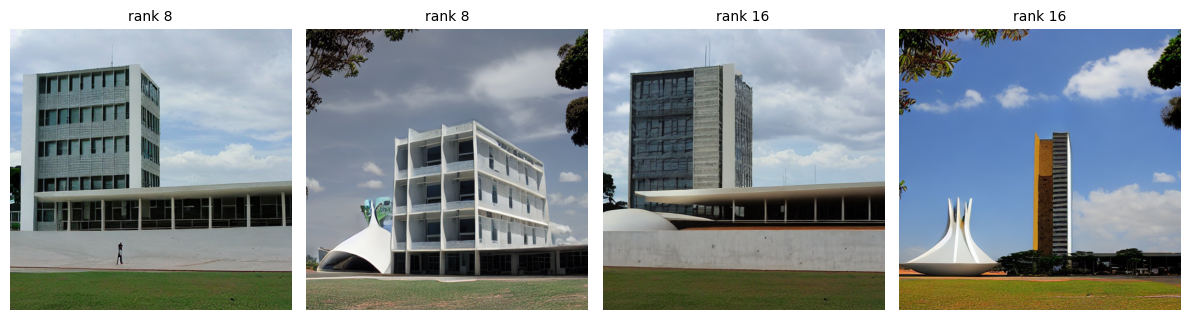

Prompt usado (fora do dataset): estilo_brasilia, uma escola modernista com colunas curvas de concreto branco


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

todas = [(p, "rank 8") for p in imgs_rank8] + [(p, "rank 16") for p in imgs_rank16]

fig, axes = plt.subplots(1, len(todas), figsize=(len(todas) * 3, 3.5))
for ax, (caminho, rotulo) in zip(axes, todas):
    img = Image.open(caminho)
    ax.imshow(img)
    ax.set_title(rotulo, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Prompt usado (fora do dataset):", PROMPT_VALIDACAO)



## Testar os 6 prompts fixos (preparação para a Etapa 3)



In [9]:
PROMPTS_TESTE = [
    "estilo_brasilia, Congresso Nacional ao entardecer com céu alaranjado",
    "estilo_brasilia, Catedral Católica vista de ângulo do sol em dia ensolarado",
    "estilo_brasilia, Palácio do Planalto à noite com fachada iluminada e lua cheia",
    "estilo_brasilia, museu moderno com sob céu nublado",
    "estilo_brasilia, uma escola com colunas curvas de concreto no estilo de Brasília",
    "estilo_brasilia, parque da cidade em dia de céu azul",
]

assert len(PROMPTS_TESTE) == 6, "A Etapa 3 exige exatamente 6 prompts fixos de teste."

PASTA_GRADE = "/content/drive/MyDrive/atelie-generativo/grade_prompts_teste"
os.makedirs(PASTA_GRADE, exist_ok=True)

resultados_lora = {"rank8": {}, "rank16": {}}

for rotulo, pasta_lora in [("rank8", SAIDA_RANK8), ("rank16", SAIDA_RANK16)]:
    print(f"\nCarregando pipeline — {rotulo}...")
    pipe = carregar_pipeline(pasta_lora)

    for idx, prompt in enumerate(PROMPTS_TESTE, start=1):
        rotulo_arquivo = f"{rotulo}_prompt{idx}"
        print(f"  Gerando prompt {idx}/6: {prompt[:60]}...")
        caminhos = gerar_imagens(pipe, prompt, rotulo_arquivo, PASTA_GRADE, n=1)
        resultados_lora[rotulo][prompt] = caminhos[0]

    del pipe
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"\nGrade de {len(PROMPTS_TESTE)} prompts × 2 configurações salva em: {PASTA_GRADE}")



Carregando pipeline — rank8...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

  Gerando prompt 1/6: estilo_brasilia, Congresso Nacional ao entardecer com céu al...


...

  Gerando prompt 5/6: estilo_brasilia, uma escola com colunas curvas de concreto n...


  0%|          | 0/20 [00:00<?, ?it/s]

  Gerando prompt 6/6: estilo_brasilia, parque da cidade em dia de céu azul...


  0%|          | 0/20 [00:00<?, ?it/s]


Grade de 6 prompts × 2 configurações salva em: /content/drive/MyDrive/atelie-generativo/grade_prompts_teste


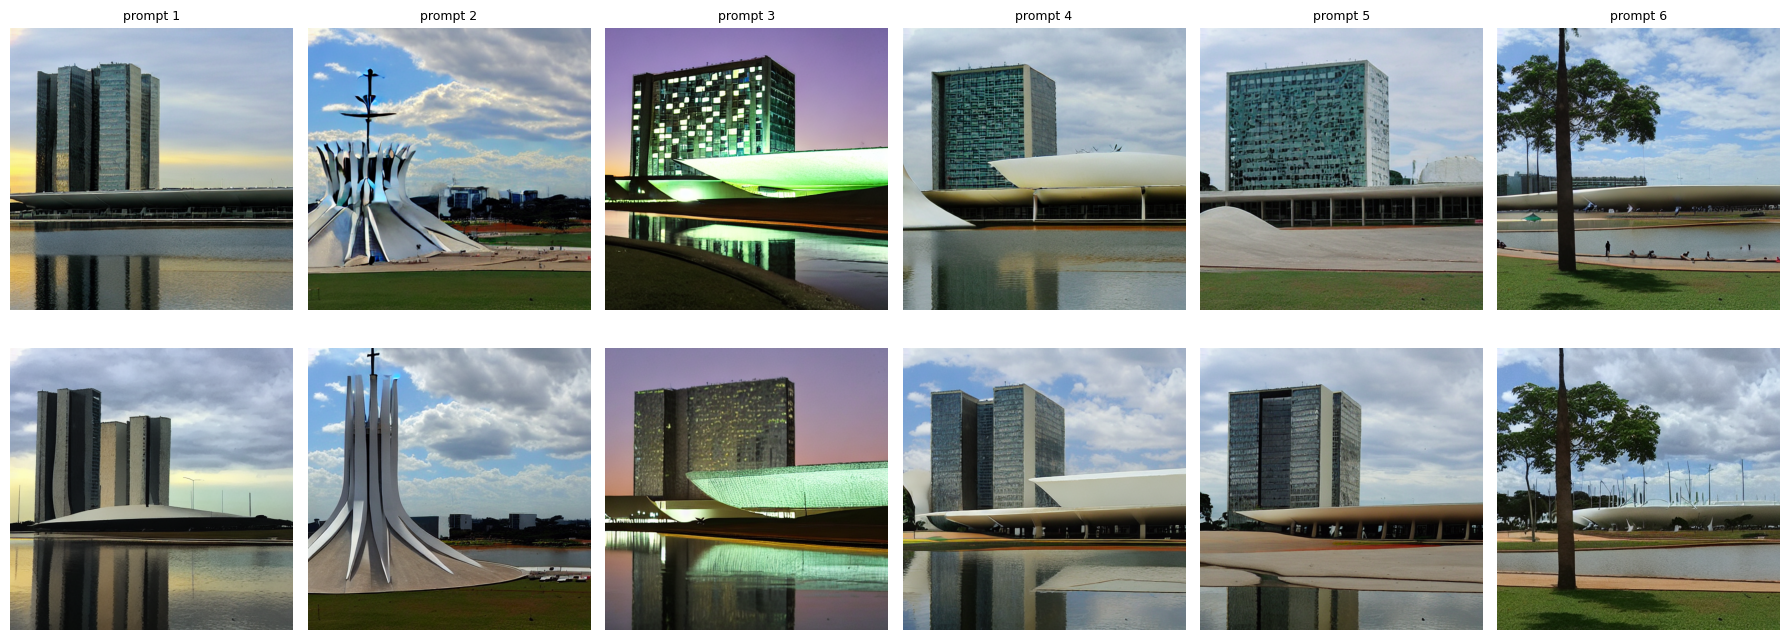

Prompts testados:
  1. estilo_brasilia, Congresso Nacional ao entardecer com céu alaranjado
  2. estilo_brasilia, Catedral Católica vista de ângulo do sol em dia ensolarado
  3. estilo_brasilia, Palácio do Planalto à noite com fachada iluminada e lua cheia
  4. estilo_brasilia, museu moderno com sob céu nublado
  5. estilo_brasilia, uma escola com colunas curvas de concreto no estilo de Brasília
  6. estilo_brasilia, parque da cidade em dia de céu azul


In [10]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, len(PROMPTS_TESTE), figsize=(len(PROMPTS_TESTE) * 3, 7))

for col, prompt in enumerate(PROMPTS_TESTE):
    for row, rotulo in enumerate(["rank8", "rank16"]):
        caminho = resultados_lora[rotulo][prompt]
        img = Image.open(caminho)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"prompt {col + 1}", fontsize=9)
        if col == 0:
            axes[row, col].set_ylabel(rotulo, fontsize=10)

plt.tight_layout()
plt.show()

print("Prompts testados:")
for i, p in enumerate(PROMPTS_TESTE, start=1):
    print(f"  {i}. {p}")


## Validação do ClipScore (Openai)

In [13]:
import torch
from transformers import CLIPModel, CLIPProcessor
from PIL import Image

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch16").to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch16")

def calcular_clip_score(caminho_imagem, prompt):
    img = Image.open(caminho_imagem).convert("RGB")
    entradas = clip_processor(text=[prompt], images=img, return_tensors="pt", padding=True).to(DEVICE)
    with torch.no_grad():
        saida = clip_model(**entradas)
    emb_imagem = saida.image_embeds / saida.image_embeds.norm(p=2, dim=-1, keepdim=True)
    emb_texto = saida.text_embeds / saida.text_embeds.norm(p=2, dim=-1, keepdim=True)
    similaridade = (emb_imagem @ emb_texto.T).item()
    return max(similaridade, 0) * 100  # fórmula padrão do CLIPScore

CONFIG_ESCOLHIDA = "rank16"

scores = []
for prompt, caminho in resultados_lora[CONFIG_ESCOLHIDA].items():
    s = calcular_clip_score(caminho, prompt)
    scores.append(s)
    print(f"{s:.2f} — {prompt[:60]}")

print(f"\nCLIPScore médio ({CONFIG_ESCOLHIDA}): {sum(scores)/len(scores):.2f}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

32.61 — estilo_brasilia, Congresso Nacional ao entardecer com céu al
36.17 — estilo_brasilia, Catedral Católica vista de ângulo do sol em
32.36 — estilo_brasilia, Palácio do Planalto à noite com fachada ilu
31.83 — estilo_brasilia, museu moderno com sob céu nublado
33.55 — estilo_brasilia, uma escola com colunas curvas de concreto n
33.87 — estilo_brasilia, parque da cidade em dia de céu azul

CLIPScore médio (rank16): 33.40
